# 07 — Prior correction, ensembling, and knowing when to stop

After the feature road ends (notebook 06), three moves remain, and each is still one
experiment at a time: correct the prior (two competing routes), buy diversity
(ensembling), and apply the **decision boundary as the last step after model choice**.
The notebook ends where every competition should: a selection rule written before
looking at the leaderboard, and a stopping rule with numbers in it.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import polars as pl

from s6e7 import cv, decision, features, io, plots
from s6e7.cv import ExperimentConfig

pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_str_lengths(90)
train, test = io.load_train(), io.load_test()
y = features.encode_target(train[io.TARGET])

---
## 1. Prior correction: one fix, two routes

The baseline diagnostics (notebook 04) showed errors flowing into `at-risk` — argmax
maximises plain accuracy, and plain accuracy loves the 86% class. Balanced accuracy
weighs the classes equally, so the decision has to be corrected. Two ways to do it:

- **Route A — during training:** `class_weight="balanced"` reweights the loss so
  argmax becomes the right decision.
- **Route B — after training:** leave the model alone, search per-class multipliers
  `argmax_k m_k·q_k` on the OOF probabilities. Two free parameters (scale fixes the
  first at 1), a coarse-to-fine log grid, and — the honesty part — **cross-fitted**:
  the multipliers each fold is judged with were searched without that fold.

In [2]:
route_a = cv.run(ExperimentConfig(
    "exp_0008", "lgbm",
    {"categorical_feature": features.CATEGORICAL_IDX, "n_estimators": 500,
     "learning_rate": 0.05, "class_weight": "balanced"},
    features="native_cats", parent="exp_0007",
    changed="route A: class_weight=balanced on the combo (training-route prior correction)"),
    train=train, test=test, if_logged="skip")
route_b, m_b = cv.run_rule("exp_0009", "exp_0007", train=train)
print(f"route A (weights): cv {route_a.cv_mean:.5f} ± {route_a.cv_std:.5f}")
print(f"route B (rule):    cv {route_b.cv_mean:.5f} ± {route_b.cv_std:.5f}   multipliers {np.round(m_b, 2).tolist()}")

route A (weights): cv 0.94945 ± 0.00108
route B (rule):    cv 0.94931 ± 0.00115   multipliers [1.0, 17.22, 10.16]


**A dead heat — as the theory said.** The two routes implement the same correction and
land 0.00014 apart, far inside the resolution. The searched multipliers sit near the
divide-by-prior prediction (1, 14.8, 11.9) because the probabilities were shown to be
well calibrated in notebook 04 — the search mostly *confirmed* 1/π rather than fixing
calibration.

Two readings worth pausing on:

- **This one decision was worth +0.077 — twenty times everything else combined.**
  Matching the decision to the metric dominates every modelling refinement. It was
  visible from day one in the confusion matrix; the ladder just quantified it.
- **The argmax gains vanished.** exp_0004 (weights on the *default* baseline) scored
  0.94956 — statistically identical to weights-on-combo. Capacity and categorical
  splits were mostly improving the same boundary region the prior correction fixes
  wholesale. What remains after correction is irreducible class overlap.

### Is the searched rule overfitting?

The rule was *searched* on data, so it must face the same question as any fit. The
measurement is built in: the in-sample search score versus the cross-fitted score,
plus the stability of the five per-fold searches.

In [3]:
import json

proba7 = np.load(cv.OOF_DIR / "exp_0007.npy")
_, in_sample = decision.search(proba7, y)
cache = json.loads((cv.OOF_DIR / "exp_0009_rule.json").read_text())
print(f"in-sample search: {in_sample:.5f}   cross-fitted: {route_b.cv_mean:.5f}   "
      f"gap: {in_sample - route_b.cv_mean:+.5f}")
print("per-fold searched multipliers (should nearly agree):")
for k, m in enumerate(cache["fold_multipliers"]):
    print(f"  fold {k}: {m}")

in-sample search: 0.94941   cross-fitted: 0.94931   gap: +0.00011
per-fold searched multipliers (should nearly agree):
  fold 0: [1.0, 17.223, 10.161]
  fold 1: [1.0, 17.223, 13.769]
  fold 2: [1.0, 17.223, 10.161]
  fold 3: [1.0, 16.156, 10.161]
  fold 4: [1.0, 16.156, 10.161]


Two parameters against ~550k rows per search: the gap is a rounding error and the five
searches nearly agree. **That** is what "it really helps" looks like; a rule that
gained in-sample but lost cross-fitted, or whose five searches scattered, would be
fitting noise. The same construction scales to any post-processing you might tune on
OOF — thresholds, calibration, blend weights — and it is the general answer to *"how
do we see if it is overfitting or really helps":* hold out the thing you tuned on.

---
## 2. Ensembling: diversity is measured, not assumed

A blend beats its best member only where the members' *errors* decorrelate. That is a
number, not a vibe — check it before buying more models:

In [4]:
labels_lgbm = proba7.argmax(1)
labels_xgb = np.load(cv.OOF_DIR / "exp_0010.npy").argmax(1)
err_l, err_x = labels_lgbm != y, labels_xgb != y
print(f"error rate  lgbm {err_l.mean():.4f}   xgb {err_x.mean():.4f}")
print(f"both wrong  observed {(err_l & err_x).mean():.4f}   "
      f"if independent {err_l.mean() * err_x.mean():.4f}")
print(f"error correlation {np.corrcoef(err_l, err_x)[0, 1]:.3f}")

error rate  lgbm 0.0329   xgb 0.0330
both wrong  observed 0.0293   if independent 0.0011
error correlation 0.885


In [5]:
blend = cv.run_blend("exp_0011", ["exp_0007", "exp_0010"], train=train)
ruled_blend, m_blend = cv.run_rule("exp_0012", "exp_0011", train=train)
print(f"exp_0011 blend (argmax): {blend.cv_mean:.5f} ± {blend.cv_std:.5f}")
print(f"exp_0012 blend + rule:   {ruled_blend.cv_mean:.5f} ± {ruled_blend.cv_std:.5f}   "
      f"multipliers {np.round(m_blend, 2).tolist()}")

exp_0011 blend (argmax): 0.87849 ± 0.00174
exp_0012 blend + rule:   0.94955 ± 0.00138   multipliers [1.0, 17.78, 12.92]


The two GBDT families are wrong together most of the time — observed co-error is an
order of magnitude above the independence line. So the equal blend lands *between* its
parents at argmax rather than above both, and even after the rule it edges the field
by less than one resolution. **This is the "do we need a sink of models?" answer:**
stacking and bigger ensembles pay in proportion to error decorrelation, and two tree
ensembles on 13 tabular features have almost none to sell each other. The only
diversity left to buy would be a genuinely different model class — priced below the
resolution here, so not bought.

---
## 3. Selection — the rule, written before looking

> **Selection rule.** Final = the candidate with the highest `cv_mean`. Candidates
> within one resolution (0.001) of the top are a tie; ties break toward fewer moving
> parts (fewer trained models, fewer fitted parameters, fewer pipeline steps). The
> second Kaggle slot goes to the most *different* pipeline inside the tie, as
> insurance against the first pick's specific failure mode.

In [6]:
ledger = pl.read_csv(cv.LEDGER)
candidates = ledger.filter(pl.col("exp_id").is_in(["exp_0004", "exp_0008", "exp_0009", "exp_0012"]))
candidates.select("exp_id", "model", "cv_mean", "cv_std", "parent", "changed").sort("cv_mean", descending=True)

exp_id,model,cv_mean,cv_std,parent,changed
str,str,f64,f64,str,str
"""exp_0004""","""lgbm""",0.94956,0.00138,"""exp_0001""","""class_weight=balanced (training-route prior correction)"""
"""exp_0012""","""rule(exp_0011)""",0.94955,0.00138,"""exp_0011""","""decision rule: per-class multipliers, cross-fitted on OOF"""
"""exp_0008""","""lgbm""",0.94945,0.00108,"""exp_0007""","""route A: class_weight=balanced on the combo (training-route prior correction)"""
"""exp_0009""","""rule(exp_0007)""",0.94931,0.00115,"""exp_0007""","""decision rule: per-class multipliers, cross-fitted on OOF"""


Four candidates, 0.94931–0.94956: a four-way tie inside one resolution. Applying the
rule:

- **Final pick: `exp_0004`** — one LightGBM with default trees and a single changed
  parameter, `class_weight="balanced"`. The simplest object in the tie.
- **Second pick: `exp_0012`** — blend of two families plus the searched rule; the most
  different pipeline in the tie.

That the whole ladder returns to *baseline + one parameter* is not an anticlimax — it
is the ladder working. Without exps 0002–0012 that sentence would be a guess; with
them it is a measurement: every alternative was tried once, and none of them buys
anything the resolution can see.

---
## 4. When to stop — a checklist with numbers in it

Stopping is a decision like any other, so it gets criteria, not feelings:

1. **Every axis probed once and priced.** Encoding +0.0009, capacity +0.0039, features
   +0.0000 twice, prior correction +0.077, family diversity ≈ 0, blending ≈ 0 after
   correction. No axis is unexplored.
2. **The trajectory is flat inside the band.** The last four experiments span 0.00025
   — a quarter of the resolution (figure below).
3. **The next experiments are unreadable before they run.** rule(exp_0010),
   weighted-XGBoost, CatBoost, an Optuna sweep: each has a plausible best case inside
   the tie band, which means *even if it wins, we could not select it*. Declining an
   experiment you couldn't read is the stopping rule in action — that is why
   rule(exp_0010) was deliberately never run.
4. **The error profile says the rest is irreducible.** Remaining errors sit where no
   feature separates the minorities (notebook 06); no amount of model will invent
   separation the columns don't carry.
5. **CV↔LB is calibrated.** exp_0001 predicted LB 0.001–0.002 below CV and landed
   −0.0008 public / −0.0012 private. The final submission is the last point on that
   line, not a lottery ticket.

This is also the answer to *"how do we trust the strategy?"* — the ledger **is** the
strategy. Each row asked one question and got a priced answer; the route never
depended on memory or vibes, so it cannot be lost the way a pile of random experiments
is.

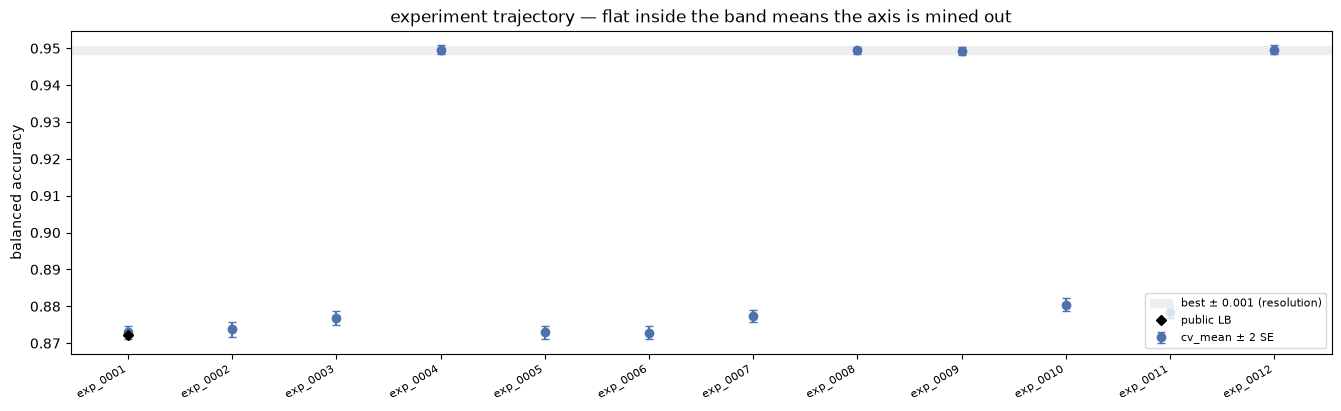

In [7]:
plots.experiment_compare(pl.read_csv(cv.LEDGER))

The picture to internalise: everything the ladder did lives in two clusters — the
argmax cluster at ~0.873–0.880 and the corrected cluster at ~0.9495 — and inside each
cluster the points are one resolution apart. One decision moved between clusters;
everything else moved within them. Notebook 08 turns the two picks into files.